# Stage 1 — Optuna Hyperparameter Search (HR&HRV Signals, 2000 Epochs, Per-subject Norm)
Cross-dataset: CATSA (train/val) → EmpaticaE4 (test)  
Signal: HR&HRV @ 32 Hz, window=60s (1920 samples), stride=10s (320 samples)  
Channels: HR, HRV (2 ch)  
Objective: maximise val-F1 (NopPruner, 15 trials / model)  
Storage: SQLite (resumable)  
**Loss**: BCEWithLogitsLoss(pos_weight) | **Epochs**: 2000 | **Early Stopping**: Optuna patience (50–100)

In [1]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import NopPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_BF16 = torch.cuda.is_available()
print(f'Device: {DEVICE}  |  BF16: {USE_BF16}')

Device: cuda  |  BF16: True


/home/binghin2/miniconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
MODELS = [
    'TimeMixerPP', 'Medformer', 'TSLANet', 'ModernTCN',
    'CrossGNN', 'TimesNet', 'Mamba2', 'iTransformer', 'PatchTST', 'Chronos2', 'TransformerCNN',
]

SIGNAL     = 'HR_HRV'
FS         = 1
WIN_SEC    = 60
STRIDE_SEC = 10
W          = FS * WIN_SEC      # 1920
STRIDE     = FS * STRIDE_SEC   # 320
N_CHANNELS = 2
TASKS        = ['Baseline', 'Logic', 'Nback', 'Stroop', 'Sudoku']
STRESS_TASKS = {'Logic', 'Nback', 'Stroop', 'Sudoku'}

VAL_RATIO = 0.10
EPOCHS    = 2000
# Early stopping: patience sampled by Optuna (50–100)

N_TRIALS  = 15

DATA_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')
SAVE_DIR  = Path('Save_model_HR_HRV_Norm')
SAVE_DIR.mkdir(exist_ok=True)
DB_PATH   = SAVE_DIR / 'optuna_studies.db'
STORAGE   = f'sqlite:///{DB_PATH}'

print(f'W={W}, stride={STRIDE}, channels={N_CHANNELS}, EPOCHS={EPOCHS}, save → {SAVE_DIR}')

W=60, stride=10, channels=2, EPOCHS=2000, save → Save_model_HR_HRV_Norm


In [3]:
# ── Data utilities ───────────────────────────────────────────────────────────
import re


def discover_subjects(root: Path) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.is_dir() and re.match(r'Sub\d+', p.name)])


def _is_numeric_like(value) -> bool:
    try:
        float(str(value).strip())
        return True
    except Exception:
        return False


def _read_csv_auto(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if len(df.columns) > 0 and all(_is_numeric_like(c) for c in df.columns):
        df = pd.read_csv(path, header=None)
    return df


def read_series(path: Path, preferred_col: str | None = None) -> np.ndarray:
    df = _read_csv_auto(path)
    if preferred_col and preferred_col in df.columns:
        series = df[preferred_col]
    else:
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if numeric_cols:
            series = df[numeric_cols[0]]
        else:
            series = df.iloc[:, 0]
    values = pd.to_numeric(series, errors='coerce').to_numpy(np.float32)
    return values[~np.isnan(values)]


def resample_1d(sig: np.ndarray, target_len: int) -> np.ndarray:
    sig = np.asarray(sig, dtype=np.float32)
    if target_len <= 0:
        return np.empty(0, np.float32)
    if sig.size == 0:
        return np.zeros(target_len, np.float32)
    if len(sig) == target_len:
        return sig.astype(np.float32, copy=False)
    x_old = np.linspace(0.0, 1.0, len(sig), dtype=np.float32)
    x_new = np.linspace(0.0, 1.0, target_len, dtype=np.float32)
    return np.interp(x_new, x_old, sig).astype(np.float32)


def detect_hrv_from_hr(hr: np.ndarray, hrv_window: int = 5) -> np.ndarray:
    hr = np.asarray(hr, dtype=np.float32)
    if hr.size == 0:
        return hr
    hr = np.clip(hr, 1e-3, None)

    rr_ms = 60000.0 / hr
    drr = np.abs(np.diff(rr_ms, prepend=rr_ms[0]))
    w = max(1, int(hrv_window))
    kernel = np.ones(w, dtype=np.float32) / float(w)

    rmssd = np.sqrt(np.convolve(drr * drr, kernel, mode='same') + 1e-8)
    rr_mean = np.convolve(rr_ms, kernel, mode='same')
    rr_sq_mean = np.convolve(rr_ms * rr_ms, kernel, mode='same')
    sdnn = np.sqrt(np.maximum(rr_sq_mean - rr_mean * rr_mean, 0.0) + 1e-8)

    hrv = 0.5 * rmssd + 0.5 * sdnn
    return hrv.astype(np.float32)


def load_modalities(task_dir: Path) -> np.ndarray:
    hr_raw = read_series(task_dir / 'HR.csv', 'HR')

    if len(hr_raw) == 0:
        raise RuntimeError(f'missing HR data in {task_dir}')

    target_len = len(hr_raw)
    hrv_raw = detect_hrv_from_hr(hr_raw)

    hr  = hr_raw.astype(np.float32)
    hrv = resample_1d(hrv_raw, target_len)

    return np.vstack([
        hr[None, :],
        hrv[None, :],
    ]).astype(np.float32)


def make_windows_3d(sig: np.ndarray, w: int, stride: int) -> np.ndarray:
    if sig.shape[-1] < w:
        return np.empty((0, sig.shape[0], w), np.float32)
    return np.asarray([
        sig[:, i:i + w] for i in range(0, sig.shape[-1] - w + 1, stride)
    ], dtype=np.float32)


def build_all_arrays(root: Path, w: int, stride: int, val_ratio: float = 0.10):
    xs, ys = [], []
    skipped = []
    for sub in discover_subjects(root):
        try:
            task_sigs = {task: load_modalities(sub / task) for task in TASKS}
            # Per-subject normalization across all tasks
            all_sig = np.concatenate(list(task_sigs.values()), axis=1)
            mu    = np.mean(all_sig, axis=1, keepdims=True)
            sigma = np.std(all_sig,  axis=1, keepdims=True) + 1e-8
            for task, sig in task_sigs.items():
                norm = (sig - mu) / sigma
                x = make_windows_3d(norm, w, stride)
                if len(x):
                    xs.append(x)
                    ys.append(np.full(len(x), int(task in STRESS_TASKS), np.int64))
        except Exception as e:
            skipped.append(f'{sub.name}: {e}')
    if skipped:
        print('Skipped subjects:')
        for item in skipped[:10]:
            print(f'  {item}')
        if len(skipped) > 10:
            print(f'  ... and {len(skipped) - 10} more')
    if not xs:
        raise RuntimeError(f'No CATSA data could be loaded from {root}')
    X = np.concatenate(xs)
    Y = np.concatenate(ys)
    split = max(1, int(len(X) * (1 - val_ratio)))
    return X[:split], Y[:split], X[split:], Y[split:]


print('Data utilities defined.')

Data utilities defined.


In [4]:
# ── E4 data loading (test only - never used for train/val) ───────────────────
E4_ROOT = Path('/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects')
SUBJECTS_E4 = [f'subject_{i:02d}' for i in range(1, 7)]


def build_e4_labels(n: int, fs: int = FS):
    fixed_s = {
        'rest0': 180, 'task1': 600, 'rest1': 120, 'task2': 300,
        'rest2': 120, 'task3': 180, 'rest3': 120, 'rest4': 120,
        'task5': 60,  'rest5': 120,
    }
    total_fixed_s = sum(fixed_s.values())
    task4_s = max(0, n // fs - total_fixed_s)
    segs = [
        ('rest0', 180, 0), ('task1', 600, 1), ('rest1', 120, -1),
        ('task2', 300, 1), ('rest2', 120, -1), ('task3', 180, 1),
        ('rest3', 120, -1), ('task4', task4_s, 1), ('rest4', 120, -1),
        ('task5', 60, 1), ('rest5', 120, -1),
    ]
    labels = np.full(n, -1, dtype=np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        if dur_s <= 0:
            continue
        end = min(cur + dur_s * fs, n)
        if end > cur:
            labels[cur:end] = lab
        cur = end
        if cur >= n:
            break
    return labels, int(task4_s)


def load_e4_modalities(subject_dir: Path) -> np.ndarray:
    hr_raw = read_series(subject_dir / 'HR.csv', 'HR')

    if len(hr_raw) == 0:
        raise RuntimeError(f'missing HR data in {subject_dir}')

    target_len = len(hr_raw)
    hrv_raw = detect_hrv_from_hr(hr_raw)

    hr  = hr_raw.astype(np.float32)
    hrv = resample_1d(hrv_raw, target_len)

    return np.vstack([
        hr[None, :],
        hrv[None, :],
    ]).astype(np.float32)


def e4_windows(sig: np.ndarray, labels: np.ndarray, W: int, S: int):
    mask  = labels >= 0
    mu    = np.mean(sig[:, mask], axis=1, keepdims=True) if mask.any() else np.mean(sig, axis=1, keepdims=True)
    sigma = np.std(sig[:, mask],  axis=1, keepdims=True) + 1e-8 if mask.any() else np.std(sig, axis=1, keepdims=True) + 1e-8
    norm = ((sig - mu) / sigma).astype(np.float32)
    xs, ys = [], []
    for i in range(0, norm.shape[-1] - W + 1, S):
        u = np.unique(labels[i:i + W])
        if len(u) == 1 and u[0] in (0, 1):
            xs.append(norm[:, i:i + W])
            ys.append(int(u[0]))
    if not xs:
        return np.empty((0, N_CHANNELS, W), np.float32), np.empty(0, np.int64)
    return np.asarray(xs, np.float32), np.asarray(ys, np.int64)


e4_data_per_subject = {}
for sub in SUBJECTS_E4:
    sig = load_e4_modalities(E4_ROOT / sub)
    labels, _ = build_e4_labels(sig.shape[-1], fs=FS)
    x, y = e4_windows(sig, labels, W, STRIDE)
    e4_data_per_subject[sub] = (x, y)
    print(f'{sub}: {len(x)} windows')

subject_01: 158 windows
subject_02: 143 windows
subject_03: 115 windows
subject_04: 118 windows
subject_05: 116 windows
subject_06: 124 windows


In [5]:
# ── Load HR&HRV data (once, shared across all models) ─────────────────────────
print('Loading HR&HRV data...', end=' ')
x_train, y_train, x_val, y_val = build_all_arrays(DATA_ROOT, W, STRIDE, VAL_RATIO)
print(f'done.  train={x_train.shape}  val={x_val.shape}')

n_stress    = (y_train == 1).sum()
n_nonstress = (y_train == 0).sum()
POS_WEIGHT  = float(n_stress / n_nonstress)
print(f'Stress={n_stress}, Non-stress={n_nonstress}, pos_weight={POS_WEIGHT:.3f}')

Loading HR&HRV data...   피험자: train=45명, val=5명
done.  train=(2919, 2, 60)  val=(325, 2, 60)
Stress=2334, Non-stress=585, pos_weight=3.990


In [6]:
# ── Chronos-2 pipeline (optional) ────────────────────────────────────────────
chronos_pipeline = None
try:
    from chronos import ChronosPipeline
    chronos_pipeline = ChronosPipeline.from_pretrained(
        'amazon/chronos-t5-small',
        device_map=str(DEVICE),
        torch_dtype=torch.float32,
    )
    print('Chronos-2 pipeline loaded.')
except Exception as e:
    print(f'Chronos-2 unavailable: {e}')
    MODELS = [m for m in MODELS if m != 'Chronos2']
    print(f'Running without Chronos2. Models: {MODELS}')

Chronos-2 unavailable: Could not import module 'PreTrainedModel'. Are this object's requirements defined correctly?
Running without Chronos2. Models: ['iTransformer']


In [7]:
# ── Import models and shared utils ───────────────────────────────────────────
import importlib.util

MODULE_DIR = Path('/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/HR&HRV')


def load_module(module_name: str, file_name: str):
    spec = importlib.util.spec_from_file_location(module_name, MODULE_DIR / file_name)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    assert spec.loader is not None
    spec.loader.exec_module(module)
    return module


load_module('HR_HRV_models_ten', 'HR&HRV_models_ten.py')
load_module('HR_HRV_optuna_utils', 'HR_HRV_optuna_utils.py')

from HR_HRV_optuna_utils import (
    evaluate_on_e4, finalize_best_checkpoint,
    sample_hp, set_seed, seed_worker,
    generate_stage1_summary, save_per_subject_results,
    plot_stage1_comparison, plot_per_subject_heatmap, save_hp_importance_plots,
)
from HR_HRV_models_ten import build_model

_ = build_model('TimeMixerPP', W=W, n_channels=N_CHANNELS)
print('HR&HRV modules imported OK.')

HR&HRV modules imported OK.


In [8]:
# ── Per-trial utilities ───────────────────────────────────────────────────────

@torch.no_grad()
def _val_metrics(model, loader, criterion, use_bf16, device):
    """Returns (val_loss, val_acc, val_f1)."""
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    all_pred, all_true = [], []
    for xb, yb in loader:
        xb   = xb.to(device, non_blocking=True)
        yb_d = yb.to(device, non_blocking=True)
        if use_bf16:
            with torch.autocast('cuda', dtype=torch.bfloat16):
                logits = model(xb)
                loss   = criterion(logits, yb_d.float())
        else:
            logits = model(xb)
            loss   = criterion(logits, yb_d.float())
        total_loss += loss.item()
        n_batches  += 1
        preds = (logits.float().sigmoid() >= 0.5).long().cpu()
        all_pred.append(preds)
        all_true.append(yb)
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_true).numpy()
    val_loss = total_loss / max(n_batches, 1)
    val_acc  = float((y_pred == y_true).mean())
    tp  = int(((y_pred == 1) & (y_true == 1)).sum())
    fp  = int(((y_pred == 1) & (y_true == 0)).sum())
    fn  = int(((y_pred == 0) & (y_true == 1)).sum())
    prec   = tp / (tp + fp + 1e-8)
    rec    = tp / (tp + fn + 1e-8)
    val_f1 = float(2 * prec * rec / (prec + rec + 1e-8))
    return val_loss, val_acc, val_f1


def make_objective_2000(
    model_name, x_train, y_train, x_val, y_val,
    W, n_channels, pos_weight, device, save_dir,
    epochs=2000, chronos_pipeline=None,
):
    """
    Objective with early stopping (patience sampled by Optuna) + BCEWithLogitsLoss(pos_weight).
    Returns (objective, best_f1_ref, best_hp_ref, trial_histories)
    """
    save_dir   = Path(save_dir)
    is_chronos = (model_name == 'Chronos2')
    use_bf16   = (not is_chronos) and torch.cuda.is_available()

    best_f1_ref: list[float] = [-1.0]
    best_hp_ref: list[dict]  = [{}]
    trial_histories: dict    = {}

    tmp_dir = save_dir / 'tmp_checkpoints' / model_name
    tmp_dir.mkdir(parents=True, exist_ok=True)

    xt = torch.from_numpy(x_train).float()
    yt = torch.from_numpy(y_train).long()
    xv = torch.from_numpy(x_val).float()
    yv = torch.from_numpy(y_val).long()
    val_ds = TensorDataset(xv, yv)

    def objective(trial: optuna.Trial) -> float:
        set_seed(42)
        hp       = sample_hp(trial, model_name)
        bs       = int(hp.pop('bs'))
        lr       = float(hp.pop('lr'))
        wd       = float(hp.pop('wd'))
        patience = trial.suggest_int('patience', 50, 100)

        g = torch.Generator()
        g.manual_seed(42)
        train_ds     = TensorDataset(xt, yt)
        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True,
                                  num_workers=2, pin_memory=True, drop_last=True,
                                  worker_init_fn=seed_worker, generator=g)
        val_loader   = DataLoader(val_ds,   batch_size=bs, shuffle=False,
                                  num_workers=2, pin_memory=True,
                                  worker_init_fn=seed_worker, generator=g)

        if is_chronos:
            if chronos_pipeline is None:
                raise optuna.TrialPruned()
            model = build_model(model_name, W=W, n_channels=n_channels,
                                pipeline=chronos_pipeline, **hp)
            enc_params, head_params = [], []
            for n, p in model.named_parameters():
                if p.requires_grad:
                    (enc_params if 'head' not in n else head_params).append(p)
            optimizer = torch.optim.AdamW([
                {'params': enc_params,  'lr': lr * 0.1},
                {'params': head_params, 'lr': lr},
            ], weight_decay=wd)
        else:
            model     = build_model(model_name, W=W, n_channels=n_channels, **hp)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

        model     = model.to(device)
        pw        = torch.tensor([pos_weight], dtype=torch.float32, device=device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=lr * 0.01)

        best_f1    = -1.0
        no_improve = 0
        ckpt_path  = tmp_dir / f'trial_{trial.number}.pt'
        trial_histories[trial.number] = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

        for epoch in range(epochs):
            # ── train ──
            model.train()
            epoch_loss = 0.0
            n_batches  = 0
            for xb, yb in train_loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                if use_bf16:
                    with torch.autocast('cuda', dtype=torch.bfloat16):
                        loss = criterion(model(xb), yb.float())
                else:
                    loss = criterion(model(xb), yb.float())
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item()
                n_batches  += 1
            scheduler.step()

            train_loss_ep = epoch_loss / max(n_batches, 1)

            # ── validate ──
            val_loss_ep, val_acc_ep, val_f1_ep = _val_metrics(
                model, val_loader, criterion,
                use_bf16 and not is_chronos, device)

            trial_histories[trial.number]['train_loss'].append(train_loss_ep)
            trial_histories[trial.number]['val_loss'].append(val_loss_ep)
            trial_histories[trial.number]['val_acc'].append(val_acc_ep)
            trial_histories[trial.number]['val_f1'].append(val_f1_ep)

            trial.report(val_f1_ep, epoch)

            if val_f1_ep > best_f1:
                best_f1    = val_f1_ep
                no_improve = 0
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'hp': {**hp, 'lr': lr, 'wd': wd, 'bs': bs, 'patience': patience},
                    'epoch': epoch,
                    'val_f1': val_f1_ep,
                    'trial_number': trial.number,
                    'model_name': model_name,
                }, ckpt_path)
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

        if best_f1 > best_f1_ref[0]:
            best_f1_ref[0] = best_f1
            best_hp_ref[0] = {**hp, 'lr': lr, 'wd': wd, 'bs': bs, 'patience': patience}

        del model
        torch.cuda.empty_cache()
        return best_f1

    return objective, best_f1_ref, best_hp_ref, trial_histories


def make_callbacks(model_name: str, trial_histories: dict):
    """Progress log + per-trial loss/accuracy plot."""
    def callback(study: optuna.Study, trial: optuna.Trial):
        n_done   = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
        n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
        best_val = study.best_value if study.best_trial is not None else float('nan')
        val_str  = f'{trial.value:.4f}' if trial.value is not None else 'pruned'
        print(f'  [{model_name}] trial {trial.number:>2d} ({trial.state.name:<9s}) '
              f'val_f1={val_str}  best={best_val:.4f}  '
              f'(done={n_done}, pruned={n_pruned})')

        history      = trial_histories.get(trial.number, {})
        train_losses = history.get('train_loss', [])
        val_losses   = history.get('val_loss',   [])
        val_accs     = history.get('val_acc',    [])
        val_f1s      = history.get('val_f1',     [])

        if not train_losses:
            return

        ep = range(1, len(train_losses) + 1)
        fig, ax1 = plt.subplots(figsize=(13, 4))

        ax1.plot(ep, train_losses, color='steelblue', linewidth=1.2, label='Train Loss')
        ax1.plot(ep, val_losses,   color='tomato',    linewidth=1.2, label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        ax2 = ax1.twinx()
        ax2.plot(ep, val_accs, color='seagreen', linewidth=1.2,
                 linestyle='--', label='Val Accuracy')
        if val_f1s:
            ax2.plot(ep, val_f1s, color='darkorange', linewidth=1.2,
                     linestyle=':', label='Val F1')
        ax2.set_ylabel('Accuracy / F1', color='seagreen')
        ax2.tick_params(axis='y', labelcolor='seagreen')
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc='upper right')

        title = f'{model_name}  Trial {trial.number}'
        if trial.value is not None:
            title += f'  |  best val_f1 = {trial.value:.4f}'
        ax1.set_title(title)

        plt.tight_layout()
        plt.show()

    return callback


print('_val_metrics / make_objective_2000 / make_callbacks defined.')

_val_metrics / make_objective_2000 / make_callbacks defined.


In [9]:
# ── Optuna search loop ────────────────────────────────────────────────────────
import time

e4_results_all: dict[str, dict | None] = {}
study_results:  dict[str, optuna.Study | None] = {}
all_results:    list[dict] = []

for model_name in MODELS:
    study_name = f'stage1_Norm_{SIGNAL}_{model_name}'
    print(f'\n{"="*60}')
    print(f' Model: {model_name}   study: {study_name}')
    print(f'{"="*60}')

    sampler = TPESampler(n_startup_trials=3, multivariate=True, seed=42)
    pruner  = NopPruner()

    study = optuna.create_study(
        study_name=study_name,
        storage=STORAGE,
        sampler=sampler,
        pruner=pruner,
        direction='maximize',
        load_if_exists=True,
    )

    n_done = len([t for t in study.trials
                  if t.state in (optuna.trial.TrialState.COMPLETE,
                                 optuna.trial.TrialState.PRUNED)])
    n_remaining = max(0, N_TRIALS - n_done)

    if n_remaining == 0:
        print(f'  Already completed {n_done} trials — skipping.')
    else:
        print(f'  Resuming from trial {n_done}, running {n_remaining} more.')
        t0 = time.perf_counter()

        objective, best_f1_ref, best_hp_ref, trial_histories = make_objective_2000(
            model_name=model_name,
            x_train=x_train, y_train=y_train,
            x_val=x_val,     y_val=y_val,
            W=W, n_channels=N_CHANNELS,
            pos_weight=POS_WEIGHT,
            device=DEVICE,
            save_dir=SAVE_DIR,
            epochs=EPOCHS,
            chronos_pipeline=chronos_pipeline,
        )
        study.optimize(
            objective,
            n_trials=n_remaining,
            callbacks=[make_callbacks(model_name, trial_histories)],
            catch=(Exception,),
        )
        elapsed_min = (time.perf_counter() - t0) / 60.0
        study.set_user_attr('total_time_min', elapsed_min)

    study_results[model_name] = study
    best_ckpt_path = finalize_best_checkpoint(study, model_name, SAVE_DIR)

    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if completed:
        best_trial = max(completed, key=lambda t: t.value)
        model_row = {
            'model':    model_name,
            'val_f1':   best_trial.value,
            'trial_no': best_trial.number,
            **best_trial.params,
        }
        print(f'  Best: trial {best_trial.number}  val_f1={best_trial.value:.4f}')
        print(f'  Params: {best_trial.params}')

        if best_ckpt_path is not None:
            ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
            best_hp = {k: v for k, v in ckpt['hp'].items() if k not in {'bs', 'lr', 'wd', 'patience'}}
            if model_name == 'Chronos2':
                best_hp['pipeline'] = chronos_pipeline
            best_model = build_model(model_name, W=W, n_channels=N_CHANNELS, **best_hp).to(DEVICE)
            best_model.load_state_dict(ckpt['model_state_dict'])

            e4_result = evaluate_on_e4(best_model, e4_data_per_subject, DEVICE, use_bf16=USE_BF16)
            e4_results_all[model_name] = e4_result
            model_row['e4_accuracy']  = e4_result['overall']['accuracy']  if e4_result['overall'] else float('nan')
            model_row['e4_f1']        = e4_result['overall']['f1']        if e4_result['overall'] else float('nan')
            model_row['e4_precision'] = e4_result['overall']['precision'] if e4_result['overall'] else float('nan')
            model_row['e4_recall']    = e4_result['overall']['recall']    if e4_result['overall'] else float('nan')
            model_row['e4_auroc']     = e4_result['overall'].get('auroc', float('nan')) if e4_result['overall'] else float('nan')
            print(f"  E4 Overall F1: {model_row['e4_f1']:.4f}")
            del best_model
            torch.cuda.empty_cache()
        else:
            e4_results_all[model_name] = None
            for k in ('e4_accuracy', 'e4_f1', 'e4_precision', 'e4_recall', 'e4_auroc'):
                model_row[k] = float('nan')

        all_results.append(model_row)
    else:
        all_results.append({
            'model': model_name, 'val_f1': float('nan'), 'trial_no': -1,
            'e4_accuracy': float('nan'), 'e4_f1': float('nan'),
            'e4_precision': float('nan'), 'e4_recall': float('nan'), 'e4_auroc': float('nan'),
        })
        e4_results_all[model_name] = None
        print('  No completed trials.')

print('\nSearch complete.')


 Model: iTransformer   study: stage1_Norm_HR_HRV_iTransformer
  Already completed 15 trials — skipping.
  Best: trial 12  val_f1=0.8981
  Params: {'lr': 0.00014206022289968203, 'wd': 0.0005589249518555286, 'dropout': 0.14631566043242208, 'bs': 32, 'd_model': 256, 'n_heads': 8, 'n_layers': 3, 'd_ff': 128, 'patience': 62}

Search complete.


In [10]:
# ── Results summary ───────────────────────────────────────────────────────────
df = pd.DataFrame(all_results).sort_values('val_f1', ascending=False).reset_index(drop=True)
csv_path = SAVE_DIR / 'optuna_stage1_results.csv'
df.to_csv(csv_path, index=False)
print(f'Saved → {csv_path}')
display(df[['model', 'val_f1', 'e4_f1', 'e4_accuracy', 'trial_no']].round(4))

e4_json_path = SAVE_DIR / 'e4_results_stage1.json'
with open(e4_json_path, 'w') as f:
    json.dump(e4_results_all, f, indent=2)
print(f'E4 results saved → {e4_json_path}')

Saved → Save_model_HR_HRV_Norm/optuna_stage1_results.csv


,model,val_f1,e4_f1,e4_accuracy,trial_no
0,iTransformer,0.8981,NaN,NaN,12


E4 results saved → Save_model_HR_HRV_Norm/e4_results_stage1.json


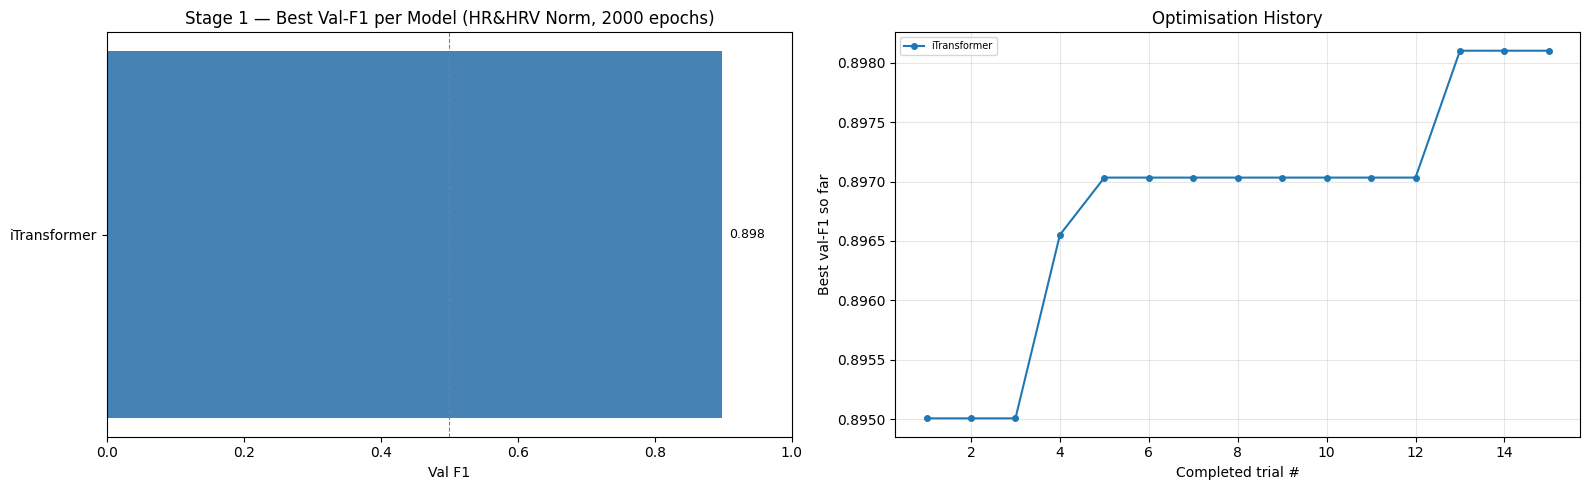

Figure saved → Save_model_HR_HRV_Norm/optuna_stage1_results.png


In [11]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ['steelblue' if v >= 0.5 else 'salmon' for v in df['val_f1'].fillna(0)]
ax.barh(df['model'], df['val_f1'].fillna(0), color=colors)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Val F1')
ax.set_title('Stage 1 — Best Val-F1 per Model (HR&HRV Norm, 2000 epochs)')
ax.set_xlim(0, 1)
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row['val_f1'] + 0.01 if not pd.isna(row['val_f1']) else 0.01,
            i, f"{row['val_f1']:.3f}" if not pd.isna(row['val_f1']) else 'N/A',
            va='center', fontsize=9)

ax2 = axes[1]
for model_name in MODELS:
    study_name = f'stage1_Norm_{SIGNAL}_{model_name}'
    try:
        study = optuna.load_study(study_name=study_name, storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if completed:
            vals = [t.value for t in completed]
            best_so_far = [max(vals[:i+1]) for i in range(len(vals))]
            ax2.plot(range(1, len(best_so_far) + 1), best_so_far,
                     marker='o', markersize=4, label=model_name)
    except Exception:
        pass
ax2.set_xlabel('Completed trial #')
ax2.set_ylabel('Best val-F1 so far')
ax2.set_title('Optimisation History')
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = SAVE_DIR / 'optuna_stage1_results.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved → {fig_path}')

In [12]:
# ── Stage 1 Summary / Comparison Artifacts ───────────────────────────────────
import importlib
ou = sys.modules['HR_HRV_optuna_utils']
ou = importlib.reload(ou)
sys.modules['HR_HRV_optuna_utils'] = ou

summary_df     = ou.generate_stage1_summary(study_results, e4_results_all, SAVE_DIR)
per_subject_df = ou.save_per_subject_results(e4_results_all, SAVE_DIR)

print('\n=== Stage 1 Summary (sorted by E4 F1) ===')
try:
    display(
        summary_df[['model', 'status', 'best_val_f1', 'e4_f1', 'e4_accuracy',
                    'e4_precision', 'e4_recall', 'e4_auroc',
                    'n_trials_completed', 'n_trials_pruned']]
        .style
        .format({c: '{:.4f}' for c in ['best_val_f1', 'e4_f1', 'e4_accuracy',
                                       'e4_precision', 'e4_recall', 'e4_auroc']},
                na_rep='N/A')
        .background_gradient(cmap='YlGn', subset=['best_val_f1', 'e4_f1'])
    )
except Exception:
    print(summary_df)

summary_json_path = SAVE_DIR / 'stage1_summary.json'
summary_df.to_json(summary_json_path, orient='records', indent=2)
print(f'Saved: {summary_json_path}')

Saved: Save_model_HR_HRV_Norm/stage1_summary.csv
Saved: Save_model_HR_HRV_Norm/stage1_per_subject.csv

=== Stage 1 Summary (sorted by E4 F1) ===


,model,status,best_val_f1,e4_f1,e4_accuracy,e4_precision,e4_recall,e4_auroc,n_trials_completed,n_trials_pruned
0,iTransformer,OK,0.8981,N/A,N/A,N/A,N/A,N/A,15,0


Saved: Save_model_HR_HRV_Norm/stage1_summary.json


In [13]:
# ── Stage 1 Comparison Figures ────────────────────────────────────────────────
ou.plot_stage1_comparison(summary_df, study_results, SAVE_DIR, signal_name=SIGNAL)
ou.plot_per_subject_heatmap(per_subject_df, SAVE_DIR, metric='f1')
ou.save_hp_importance_plots(study_results, SAVE_DIR)

print('\nComparison artifacts generated.')

No valid results to plot.
No per-subject data to plot.
Plots saved to: Save_model_HR_HRV_Norm/optuna_results

Comparison artifacts generated.


In [14]:
# ── Best HPs per model (saved as JSON) ───────────────────────────────────────
best_hp_all: dict[str, dict] = {}
for model_name in MODELS:
    study_name = f'stage1_Norm_{SIGNAL}_{model_name}'
    try:
        study = optuna.load_study(study_name=study_name, storage=STORAGE)
        completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
        if completed:
            best_trial = max(completed, key=lambda t: t.value)
            best_hp_all[model_name] = best_trial.params
    except Exception:
        pass

hp_json_path = SAVE_DIR / 'best_hp_stage1.json'
with open(hp_json_path, 'w') as f:
    json.dump(best_hp_all, f, indent=2)
print(f'Best HPs saved → {hp_json_path}')
for m, hp in best_hp_all.items():
    print(f'  {m:<16s}: {hp}')

Best HPs saved → Save_model_HR_HRV_Norm/best_hp_stage1.json
  iTransformer    : {'lr': 0.00014206022289968203, 'wd': 0.0005589249518555286, 'dropout': 0.14631566043242208, 'bs': 32, 'd_model': 256, 'n_heads': 8, 'n_layers': 3, 'd_ff': 128, 'patience': 62}


In [15]:
# ── Final Stage 1 Report ──────────────────────────────────────────────────────
print('\n' + '=' * 72)
print('STAGE 1 BASELINE RESULTS  (HR&HRV signals, 2000 epochs, per-subject norm)')
print('=' * 72)

valid = summary_df.dropna(subset=['e4_f1']).copy()
if len(valid) > 0:
    print('\nTop 3 models by E4 F1:')
    for rank, (_, row) in enumerate(valid.head(3).iterrows(), start=1):
        print(f"  {rank}. {row['model']:15s} | E4 F1: {row['e4_f1']:.4f} | Val F1: {row['best_val_f1']:.4f}")

    best_row = valid.iloc[0]
    print(f"\nBest model: {best_row['model']}")
    print(f"  Best HPs: lr={best_row['best_lr']:.2e}, bs={int(best_row['best_batch_size'])}, dropout={best_row['best_dropout']:.2f}")
    print(f"  Weight decay={best_row['best_weight_decay']:.2e}")
    print(f"  Model-specific: {best_row['best_model_specific']}")
    print(f"  E4 metrics: F1={best_row['e4_f1']:.4f}, Acc={best_row['e4_accuracy']:.4f}, AUROC={best_row['e4_auroc']:.4f}")

failed = summary_df[summary_df['status'] == 'FAILED']
if len(failed) > 0:
    print(f"\nFailed models: {failed['model'].tolist()}")

print('\nSaved outputs:')
print(f"  {SAVE_DIR / 'stage1_summary.csv'}")
print(f"  {SAVE_DIR / 'stage1_per_subject.csv'}")
print(f"  {SAVE_DIR / 'stage1_comparison.png'}")
print(f"  {SAVE_DIR / 'stage1_per_subject_heatmap_f1.png'}")
print(f"  {SAVE_DIR / 'optuna_results'}")
print('=' * 72)


STAGE 1 BASELINE RESULTS  (HR&HRV signals, 2000 epochs, per-subject norm)

Saved outputs:
  Save_model_HR_HRV_Norm/stage1_summary.csv
  Save_model_HR_HRV_Norm/stage1_per_subject.csv
  Save_model_HR_HRV_Norm/stage1_comparison.png
  Save_model_HR_HRV_Norm/stage1_per_subject_heatmap_f1.png
  Save_model_HR_HRV_Norm/optuna_results
